# FINANCE 384 --- Lecture 3

## Portfolio Optimization as a Regression Problem

Companion to **Application 3** of the lecture. Britten-Jones (1999) shows that Markowitz
portfolio weights can be recovered from a regression: regress a column of ones on the
excess returns of $N$ assets, with no intercept,

$$\mathbf{1}_T = \mathbf{R}^e\boldsymbol{\theta} + \boldsymbol{\eta},$$

then rescale the fitted coefficients so they sum to one.

Once portfolio weights are regression coefficients, they are estimates with sampling
error --- and the penalties from the rest of the lecture apply to them directly.

**After this notebook you should be able to:**

1. obtain Markowitz weights from a regression, and check them against the textbook rule;
2. show the unregularized weights are extreme;
3. apply Tikhonov ($\ell_2$) and $\ell_1$ penalties to those weights and describe what each does;
4. tune the penalty on validation months and evaluate out of sample against $1/N$.


## 1. Setup and data

The Lecture 1 panel is unbalanced, so we keep only the stocks present in **every** month.
That makes $\mathbf{R}^e$ a time-series data set, and it suffers from survivorship bias.

**One practical trap.** `Ridge(alpha)` is exactly the lecture's $\lambda$; `Lasso(alpha)`
is not, because `scikit-learn` scales the lasso objective by the sample size.

`fit_intercept=False` throughout: an intercept would let the model fit the column of ones
without using the assets at all, and the coefficients would stop being portfolio weights.


In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

SEED = 384
MONTHS_PER_YEAR = 12
TRAIN_END = pd.Timestamp("2014-12-31")    # last month used to estimate weights
VALID_END = pd.Timestamp("2019-12-31")    # last month used to choose the penalty

BLUE = "#003865"
GREEN = "#64A70B"
GOLD = "#F2A900"
RED = "#DA291C"


In [22]:
panel_path = Path("FINANCE384_topic1_lecture_panel.csv")

panel = pd.read_csv(panel_path, parse_dates=["date"])

# Keep the stocks observed in every month
n_months = panel["date"].nunique()
months_per_stock = panel.groupby("permno")["date"].nunique()
survivors = months_per_stock[months_per_stock == n_months].index
survivor_rows = panel[panel["permno"].isin(survivors)]

# Label the columns with each firm's most recent ticker: permnos are stable, tickers are
# not (CHV -> CVX, UTX -> RTX)
last_ticker = survivor_rows.sort_values("date").groupby("permno")["ticker"].last()

excess_returns = survivor_rows.pivot(index="date", columns="permno", values="ret_excess_t")
excess_returns = excess_returns.rename(columns=last_ticker).sort_index()
excess_returns = excess_returns.reindex(sorted(excess_returns.columns), axis=1)
excess_returns.columns.name = "ticker"

T = len(excess_returns)
N = excess_returns.shape[1]

print(f"Panel            : {len(panel):,} stock-months, {panel['permno'].nunique():,} stocks")
print(f"Present in all {n_months} months: {len(survivors)} stocks")
print(f"Return matrix    : T = {T} months x N = {N} assets   (T/N = {T / N:.1f})")
print(f"Missing entries  : {excess_returns.isna().sum().sum()}")
print(f"Duplicate tickers: {excess_returns.columns.duplicated().sum()}")
excess_returns.iloc[:3, :6]


Panel            : 141,886 stock-months, 1,030 stocks
Present in all 300 months: 159 stocks
Return matrix    : T = 300 months x N = 159 assets   (T/N = 1.9)
Missing entries  : 0
Duplicate tickers: 0


ticker,AAPL,ABT,ADBE,ADM,ADP,AEE
date,,,,,,
2000-01-31,0.0050,-0.1027,-0.1853,-0.0350,-0.1236,-0.0098
2000-02-29,0.1005,0.0091,0.8481,-0.1437,-0.0860,-0.0830
2000-03-31,0.1801,0.0616,0.0868,0.0201,0.1049,0.0477


## 2. Markowitz weights are regression coefficients

Regressing a column of ones on excess returns looks nothing like portfolio construction,
so the claim deserves a test rather than trust. The lecture derives the equivalence; here
we check it.

Compute the weights twice --- once from the no-intercept regression, once from the textbook
mean-variance rule $\widehat\Sigma^{-1}\widehat{\boldsymbol\mu}$ --- rescale both so they
sum to one, and compare. If Britten-Jones is right, the two vectors are the same.


In [23]:
train = excess_returns.loc[:TRAIN_END]
valid = excess_returns.loc[(excess_returns.index > TRAIN_END) & (excess_returns.index <= VALID_END)]
test = excess_returns.loc[excess_returns.index > VALID_END]

for name, block in [("train", train), ("validation", valid), ("test", test)]:
    print(f"{name:<11}: {block.index.min():%Y-%m} to {block.index.max():%Y-%m}  {len(block):>3} months")


def portfolio_weights(returns, penalty="none", alpha=0.0):
    """Britten-Jones weights: regress ones on excess returns, no intercept, rescale to sum to 1."""
    if penalty == "none":
        model = LinearRegression(fit_intercept=False)
    elif penalty == "ridge":
        model = Ridge(alpha=alpha, fit_intercept=False)
    elif penalty == "lasso":
        model = Lasso(alpha=alpha, fit_intercept=False, max_iter=200_000, random_state=SEED)
    else:
        raise ValueError("penalty must be 'none', 'ridge' or 'lasso'")

    ones = np.ones(len(returns))
    model.fit(returns.to_numpy(), ones)

    theta = model.coef_
    weights = theta / theta.sum()
    return pd.Series(weights, index=returns.columns, name="weight")


train      : 2000-01 to 2014-12  180 months
validation : 2015-01 to 2019-12   60 months
test       : 2020-01 to 2024-12   60 months


In [24]:
w_ols = portfolio_weights(train, "none")

# The textbook route: covariance matrix inverted onto the average returns
theta_markowitz = np.linalg.solve(train.cov().to_numpy(), train.mean().to_numpy())
w_markowitz = pd.Series(theta_markowitz / theta_markowitz.sum(), index=train.columns)
largest_gap = (w_ols - w_markowitz).abs().max()

print(f"Largest gap between the two routes: {largest_gap:.2e}\n")
print(f"Gross exposure  sum|w| : {w_ols.abs().sum():.1f}")
print(f"Names held short       : {100 * (w_ols < 0).mean():.0f}%")
print(f"Largest long / short   : {w_ols.max():+.1%} / {w_ols.min():+.1%}")
print(f"Equal weight, for scale: {1 / N:+.2%}")


Largest gap between the two routes: 1.18e-13

Gross exposure  sum|w| : 24.7
Names held short       : 52%
Largest long / short   : +51.6% / -40.3%
Equal weight, for scale: +0.63%


Identical to numerical precision: the regression view *is* Markowitz. And the resulting
book is levered about 25-to-1.

** the optimiser was handed 159 average returns and 12,720 covariances. The extreme positions are what happens when the noise in those estimates is inverted.


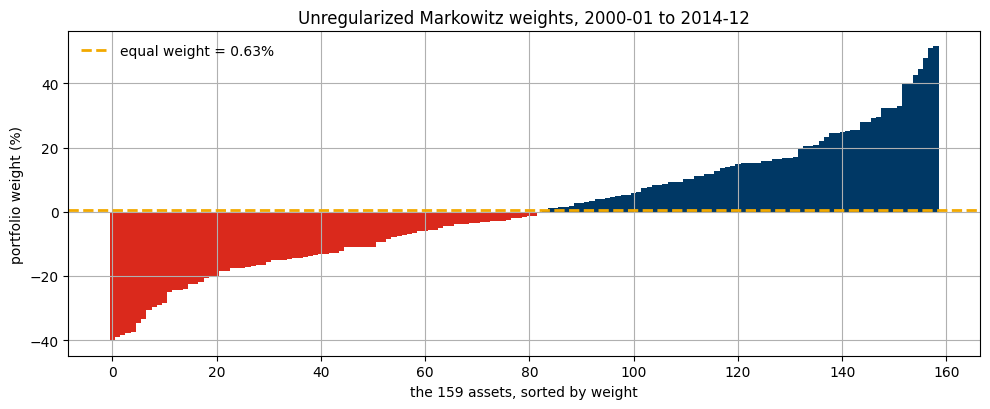

In [25]:
ordered = w_ols.sort_values()
bar_colours = []
for weight in ordered:
    if weight < 0:
        bar_colours.append(RED)
    else:
        bar_colours.append(BLUE)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(range(N), 100 * ordered.to_numpy(), color=bar_colours, width=1.0)
ax.axhline(100 / N, color=GOLD, lw=2, ls="--", label=f"equal weight = {100 / N:.2f}%")
ax.set_xlabel(f"the {N} assets, sorted by weight")
ax.set_ylabel("portfolio weight (%)")
ax.set_title(f"Unregularized Markowitz weights, {train.index.min():%Y-%m} to "
             f"{train.index.max():%Y-%m}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 3. Penalizing the weights

Tikhonov regularization penalizes the sum of squared weights. As the lecture shows, that
is the same operation as ridge --- it makes large positions expensive before the weights
are normalised --- so the estimator that stabilised a return forecast also stabilises a
portfolio.

The $\ell_1$ penalty does something different. It sets weights *exactly* to zero, so it
does not merely shrink positions. That is sparse
Markowitz, in the sense of Brodie et al. (2009).

Both effects are easier to see than to describe.


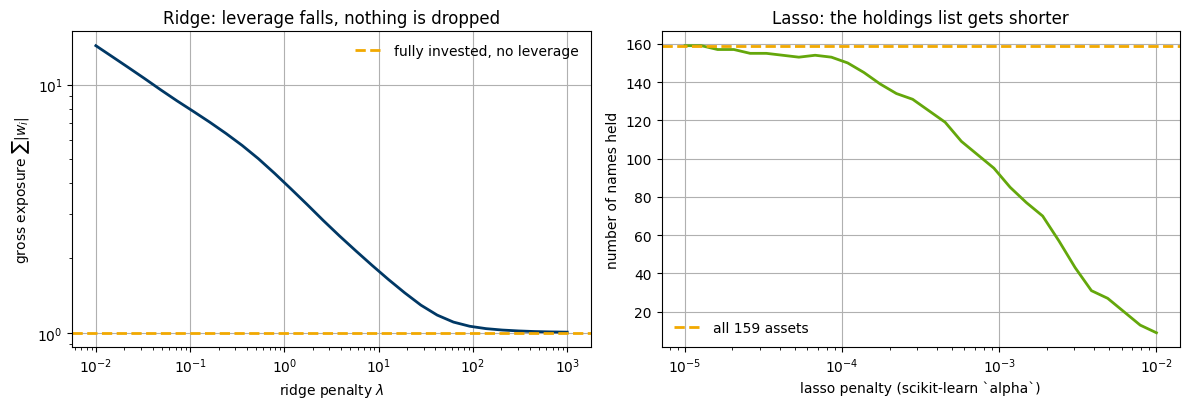

Ridge: gross exposure falls from 14.3 to 1.01, and no name is ever dropped
Lasso: names held falls from 159 to 9


In [26]:
ridge_lambdas = np.logspace(-2, 3, 30)
lasso_alphas = np.logspace(-5, -2, 30)

ridge_gross_exposure = []
for lam in ridge_lambdas:
    weights = portfolio_weights(train, "ridge", lam)
    ridge_gross_exposure.append(weights.abs().sum())

lasso_names_held = []
for alpha in lasso_alphas:
    weights = portfolio_weights(train, "lasso", alpha)
    lasso_names_held.append((weights.abs() > 1e-8).sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(ridge_lambdas, ridge_gross_exposure, color=BLUE, lw=2)
axes[0].axhline(1.0, color=GOLD, lw=2, ls="--", label="fully invested, no leverage")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"ridge penalty $\lambda$")
axes[0].set_ylabel(r"gross exposure $\sum|w_i|$")
axes[0].set_title("Ridge: leverage falls, nothing is dropped")
axes[0].legend(frameon=False)

axes[1].plot(lasso_alphas, lasso_names_held, color=GREEN, lw=2)
axes[1].axhline(N, color=GOLD, lw=2, ls="--", label=f"all {N} assets")
axes[1].set_xscale("log")
axes[1].set_xlabel("lasso penalty (scikit-learn `alpha`)")
axes[1].set_ylabel("number of names held")
axes[1].set_title("Lasso: the holdings list gets shorter")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Ridge: gross exposure falls from {ridge_gross_exposure[0]:.1f} to "
      f"{ridge_gross_exposure[-1]:.2f}, and no name is ever dropped")
print(f"Lasso: names held falls from {lasso_names_held[0]} to {lasso_names_held[-1]}")


Ridge shrinks every weight toward $1/N$ and drops nothing --- the $1/N$ portfolio is its
$\lambda \to \infty$ limit. Lasso zeroes names outright. Which you want depends on whether
the mandate caps the number of positions.

## 4. Choosing the penalty on validation months

$\lambda$ is a hyperparameter, chosen on months that come **after** the estimation months
and **before** the test months. Forecast accuracy is the wrong criterion here --- the
dependent variable is a column of ones --- so we score on the annualised Sharpe ratio an
investor would have experienced. Weights are re-estimated every month from all months
strictly before it, which is the information set available at the decision date.


In [27]:
def run_strategy(returns, dates, penalty="none", alpha=0.0, cost_bps=0.0):
    """Expanding window: estimate on every month before `date`, hold through it."""
    records = []
    previous_weights = None

    for date in dates:
        history = returns.loc[returns.index < date]
        weights = portfolio_weights(history, penalty, alpha)

        gross_return = returns.loc[date].to_numpy() @ weights.to_numpy()

        if previous_weights is None:
            turnover = 0.0
        else:
            turnover = (weights - previous_weights).abs().sum()

        records.append({
            "date": date,
            "return": gross_return - (cost_bps / 1e4) * turnover,
            "turnover": turnover,
            "names_held": (weights.abs() > 1e-8).sum(),
        })
        previous_weights = weights

    return pd.DataFrame(records).set_index("date")


def performance(returns, label):
    """Annualised mean, volatility, Sharpe ratio and maximum drawdown."""
    r = np.asarray(returns, dtype=float)

    mean = r.mean() * MONTHS_PER_YEAR
    volatility = r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR)
    sharpe = mean / volatility

    wealth = np.cumprod(1 + r)
    drawdown = wealth / np.maximum.accumulate(wealth) - 1

    return pd.Series({
        "annualised mean": mean,
        "annualised vol": volatility,
        "Sharpe ratio": sharpe,
        "max drawdown": drawdown.min(),
    }, name=label)


Ridge: best lambda = 6.31  (validation Sharpe 1.32)
Lasso: best alpha  = 0.00293  (validation Sharpe 1.20)
Unregularized      : validation Sharpe 0.11
Equal weight (1/N) : validation Sharpe 0.95


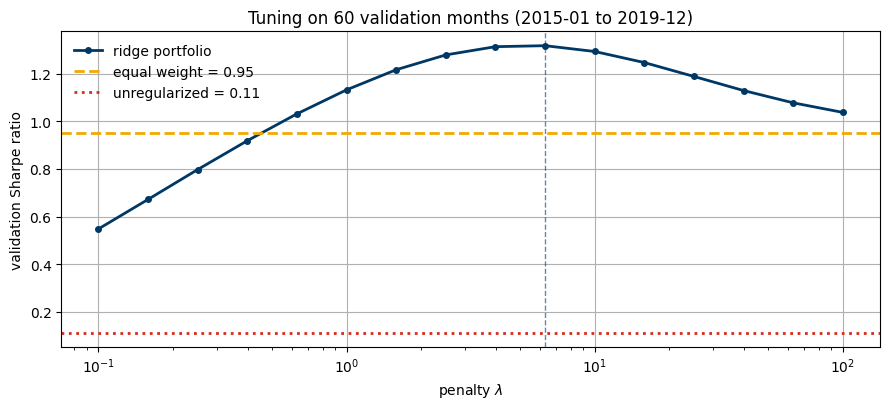

In [28]:
ridge_grid = np.logspace(-1, 2, 16)
ridge_sharpe = []
for lam in ridge_grid:
    backtest = run_strategy(excess_returns, valid.index, "ridge", lam)
    ridge_sharpe.append(performance(backtest["return"], lam)["Sharpe ratio"])

lasso_grid = np.logspace(-4, -2, 16)
lasso_sharpe = []
for alpha in lasso_grid:
    backtest = run_strategy(excess_returns, valid.index, "lasso", alpha)
    lasso_sharpe.append(performance(backtest["return"], alpha)["Sharpe ratio"])

ridge_sharpe = np.array(ridge_sharpe)
lasso_sharpe = np.array(lasso_sharpe)
best_lambda = ridge_grid[ridge_sharpe.argmax()]
best_alpha = lasso_grid[lasso_sharpe.argmax()]

equal_weight = pd.Series(np.full(N, 1 / N), index=excess_returns.columns)
ols_backtest = run_strategy(excess_returns, valid.index, "none")
ols_sharpe = performance(ols_backtest["return"], "ols")["Sharpe ratio"]
ew_sharpe = performance(valid @ equal_weight, "ew")["Sharpe ratio"]

print(f"Ridge: best lambda = {best_lambda:.2f}  (validation Sharpe {ridge_sharpe.max():.2f})")
print(f"Lasso: best alpha  = {best_alpha:.5f}  (validation Sharpe {lasso_sharpe.max():.2f})")
print(f"Unregularized      : validation Sharpe {ols_sharpe:.2f}")
print(f"Equal weight (1/N) : validation Sharpe {ew_sharpe:.2f}")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(ridge_grid, ridge_sharpe, color=BLUE, lw=2, marker="o", ms=4, label="ridge portfolio")
ax.axhline(ew_sharpe, color=GOLD, lw=2, ls="--", label=f"equal weight = {ew_sharpe:.2f}")
ax.axhline(ols_sharpe, color=RED, lw=2, ls=":", label=f"unregularized = {ols_sharpe:.2f}")
ax.axvline(best_lambda, color=BLUE, lw=1, ls="--", alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel(r"penalty $\lambda$")
ax.set_ylabel("validation Sharpe ratio")
ax.set_title(f"Tuning on {len(valid)} validation months "
             f"({valid.index.min():%Y-%m} to {valid.index.max():%Y-%m})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


The curve is the lecture's bias-variance figure read right to left: too little penalty and
the weights are nearly unregularized, too much and they converge on $1/N$. The optimum is
interior, and a long way from $\lambda = 0$ --- which is what the *Why the Optimum Sits
Left in Finance* slide predicts for a series this noisy.

Note where the two horizontal lines sit. Equal weighting, which estimates nothing, beats
the unregularized optimum on these months.

## 5. Out-of-sample test

The penalty is now fixed, so the test months can be used once.


In [29]:
methods = [
    ("unregularized (OLS)", "none", 0.0),
    (f"ridge (lambda = {best_lambda:.2f})", "ridge", best_lambda),
    (f"lasso (alpha = {best_alpha:.5f})", "lasso", best_alpha),
]

rows = []
return_paths = []

for label, penalty, alpha in methods:
    backtest = run_strategy(excess_returns, test.index, penalty, alpha)
    summary = performance(backtest["return"], label)
    summary["turnover"] = backtest["turnover"].mean()
    summary["names held"] = backtest["names_held"].mean()

    # Charge a proportional cost on the amount traded each month
    for cost in [10, 25]:
        net = run_strategy(excess_returns, test.index, penalty, alpha, cost)
        summary[f"Sharpe, {cost}bp"] = performance(net["return"], label)["Sharpe ratio"]

    rows.append(summary)
    return_paths.append((label, backtest["return"]))

# 1/N estimates nothing, so it is unaffected by the penalty and trades almost nothing
equal_weight_returns = test @ equal_weight
summary = performance(equal_weight_returns, "equal weight (1/N)")
summary["turnover"] = 0.0
summary["names held"] = N
summary["Sharpe, 10bp"] = summary["Sharpe ratio"]
summary["Sharpe, 25bp"] = summary["Sharpe ratio"]
rows.append(summary)
return_paths.append(("equal weight (1/N)", equal_weight_returns))

print(f"Test months: {test.index.min():%Y-%m} to {test.index.max():%Y-%m} "
      f"({len(test)} months), {N} assets, expanding-window re-estimation\n")
pd.DataFrame(rows).round(3)


Test months: 2020-01 to 2024-12 (60 months), 159 assets, expanding-window re-estimation



,annualised mean,annualised vol,Sharpe ratio,max drawdown,turnover,names held,"Sharpe, 10bp","Sharpe, 25bp"
unregularized (OLS),0.179,0.342,0.522,-0.301,1.439,159.000,0.472,0.397
ridge (lambda = 6.31),0.083,0.169,0.491,-0.125,0.126,159.000,0.482,0.468
lasso (alpha = 0.00293),0.136,0.219,0.621,-0.217,0.229,39.883,0.609,0.590
equal weight (1/N),0.098,0.192,0.510,-0.249,0.000,159.000,0.510,0.510


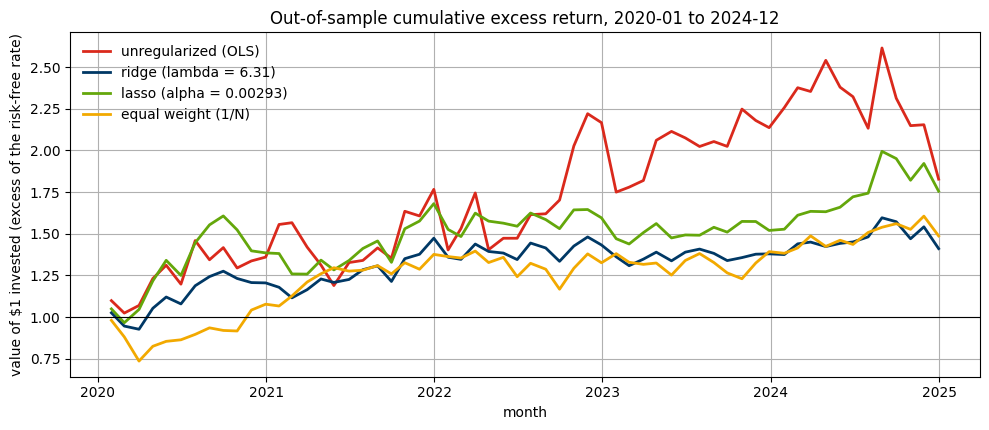

In [30]:
line_colours = [RED, BLUE, GREEN, GOLD]

fig, ax = plt.subplots(figsize=(10, 4.4))
for (label, returns), colour in zip(return_paths, line_colours):
    wealth = (1 + returns).cumprod()
    ax.plot(wealth.index, wealth, lw=2, color=colour, label=label)
ax.axhline(1.0, color="black", lw=0.8)
ax.set_ylabel("value of $1 invested (excess of the risk-free rate)")
ax.set_xlabel("month")
ax.set_title(f"Out-of-sample cumulative excess return, "
             f"{test.index.min():%Y-%m} to {test.index.max():%Y-%m}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Extension questions

1. **Change $T/N$.** Repeat Section 5 with the 40 largest survivors, so $T/N$ rises from
   about 1.9 to 7.5. Does the gap between the regularized and unregularized portfolios
   narrow, and is that what the bias-variance decomposition predicts?
3. **Shrink the covariance matrix instead.** Use `sklearn.covariance.LedoitWolf` to
   estimate the covariance matrix, then build the weights with the textbook rule
   used in Section 2. Is it better to regularize the weights or the covariances?
